### student-pass-fail-prediction
data = {
    "study_hours":  [2, 4, 6, 1, 8, 3, 7, 5, 9, 2,
                     6, 4, 8, 1, 5, 3, 7, 9, 2, 6,
                     4, 8, 1, 5, 3, 7, 9, 2, 6, 4],
    
    "attendance":   [60, 75, 85, 50, 95, 65, 90, 80, 98, 55,
                     82, 70, 93, 48, 78, 62, 88, 96, 52, 83,
                     72, 91, 45, 76, 60, 87, 94, 54, 81, 68],
   
    "prev_score":   [45, 62, 75, 38, 88, 55, 82, 70, 91, 42,
                     73, 60, 85, 35, 68, 50, 80, 90, 40, 74,
                     58, 86, 32, 66, 48, 79, 92, 44, 72, 62],
   
    "passed":       [0, 1, 1, 0, 1, 0, 1, 1, 1, 0,
                     1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
                     1, 1, 0, 1, 0, 1, 1, 0, 1, 1]
}
##### passed: 1 = Pass, 0 = Fail


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)
np.random.seed(42)

data = {
    "study_hours":  [2, 4, 6, 1, 8, 3, 7, 5, 9, 2,
                     6, 4, 8, 1, 5, 3, 7, 9, 2, 6,
                     4, 8, 1, 5, 3, 7, 9, 2, 6, 4],
    "attendance":   [60, 75, 85, 50, 95, 65, 90, 80, 98, 55,
                     82, 70, 93, 48, 78, 62, 88, 96, 52, 83,
                     72, 91, 45, 76, 60, 87, 94, 54, 81, 68],
    "prev_score":   [45, 62, 75, 38, 88, 55, 82, 70, 91, 42,
                     73, 60, 85, 35, 68, 50, 80, 90, 40, 74,
                     58, 86, 32, 66, 48, 79, 92, 44, 72, 62],
    "passed":       [0, 1, 1, 0, 1, 0, 1, 1, 1, 0,
                     1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
                     1, 1, 0, 1, 0, 1, 1, 0, 1, 1]
}



In [9]:
df=pd.DataFrame(data)
print("\nPass/Fail counts:")
print(df["passed"].value_counts())


Pass/Fail counts:
passed
1    20
0    10
Name: count, dtype: int64


### Prepare and Split


In [10]:
X = df[["study_hours", "attendance", "prev_score"]]
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24
Testing samples: 6


### Train the Model

In [17]:
model=LogisticRegression(random_state=42)
model.fit(X_train,y_train)
print("MODEL TRAINED!")

MODEL TRAINED!


###  Evaluate

In [29]:
y_pred=model.predict(X_test)
y_prob=model.predict_proba(X_test)
# Accuracy
acc=accuracy_score(y_test,y_pred)
# Full report
print("\nClassification Report:")
print(classification_report(y_test,y_pred,
                            target_names=["PASS","FAIL"]))


Classification Report:
              precision    recall  f1-score   support

        PASS       1.00      1.00      1.00         3
        FAIL       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



### Confusion matrix

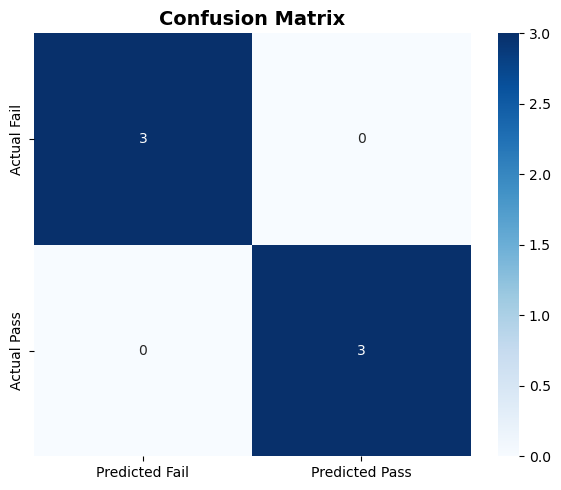

In [36]:
cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm,annot=True,cmap="Blues",
           xticklabels= ["Predicted Fail", "Predicted Pass"],
            yticklabels=["Actual Fail", "Actual Pass"]
)
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Predict a New Student

In [41]:
new_student = pd.DataFrame({
    "study_hours": [5],
    "attendance":  [75],
    "prev_score":  [65]
})
prediction=model.predict(new_student)
probability=model.predict_proba(new_student)
print(f"Prediction:{'PASS'  if prediction[0]==1 else 'Fail'}")
print(f"Probability of passing: {probability[0][1]:.2%}")

Prediction:PASS
Probability of passing: 99.98%
